<a href="https://colab.research.google.com/github/rajukarki467/learning-PyTorch/blob/main/Introduction_to_Tensor_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PyTorch**

- PyTorch is open source machine learning and deep learning framework.
- allow us to manipulate and process data and write machine learning library using python code.
- Meta,Tesla , Miceosoft and Ai research companies such as OpenAI use pytorch to power reseaech
-Tesla use pyTorch to power their self-driving computer vision task.
- agriculture to power computer vision on tractors.


- Pytorch is the most used deep learning framework on Papers with code , a website for tracking machineresearch paper and pyTorch will make sure it run fast.
- These notebook deals with the basic building block of machine learning and deep learning . the tensor.


| Topic | Content |
|---|---|
| Introduction to Tensor | Tensors are the building block of all machine learning and deep learning |
| creating tensors | Tensors can represent  almost any kind of data (image,words,tables of numbers). |
| Getting information from tensor | if we can put information into tensor, we'll want to get it out too.|
|manipulating tensors| Machine learning algorithms (like neurak network) involves manipulating tensors in many different  ways such as adding , multiplying, combining.|
| Dealing with tensor shapes | One of the most common issue in machine learning is dealing with  shape mismatches(trying to mixe wrong shaped tensors  with other tensors.)|
|indexing on tensors | if we're indexed on python list or Numpy  array.It's very similar with tensors, except they can have far more dimensions.|
| Mixing PyTorch tensors and NUmpy | PyTorch plays with tensors(torch.Tensor), NumPy like arrays(np.ndaaray) sometimeswe'll want to mix and match these.|
| Reproducibility | meachine learninf is very expermental and since it uses a lot of randomness to eork , sometimes we'll want that randomness to not be so random.|
| Running tensors on GPU | GPUs(Graphical Processing Units) make  code faster, PyTorch makes it easy to run your code on GPUs.

In [ ]:
# Importing PyTorch
import torch
torch.__version__

'2.11.0+cpu'

## Tensor:    
- Tensors are the foundamental building block of machine learning .
- to represent data in numerical way.
- for example , we could represent an image as a tensor with shape [3,224,224] which would means [colour_channels , height , width ] , as in the image has 3 Collour channels(red,green,blue) , a height of 224 pixels and a width of 224 pixels.
- 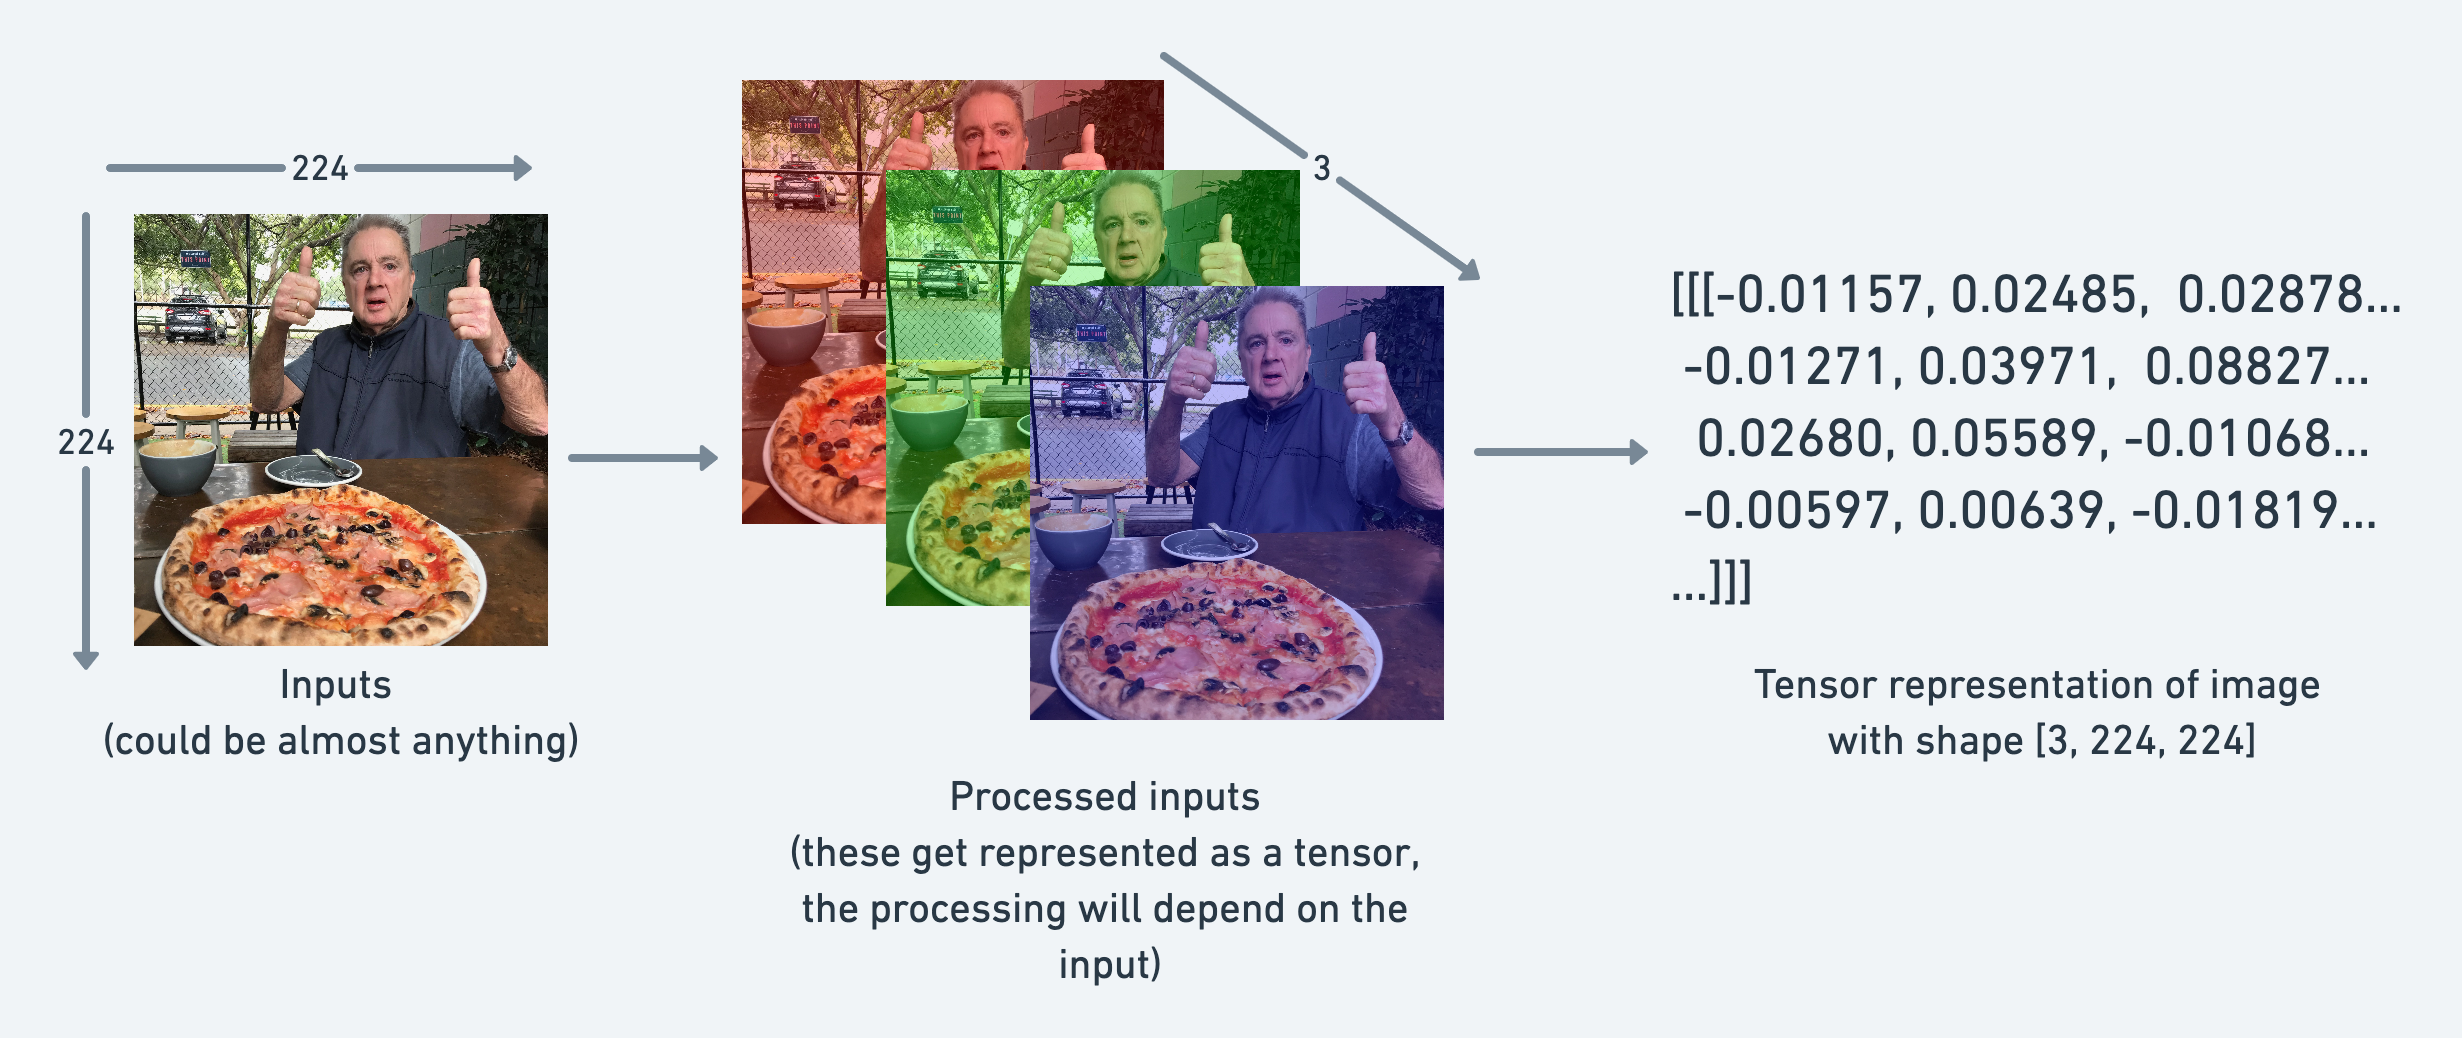

- In tensor-speak ( the language used to describe  tensors), the tensor would have three dimensions, on color colour channels, heigh and width.

###  1. Creating the tensors
- whole documentation page dedicated to tensor ( torch.Tensor) class.
- torch.tensor is the multi-dimensional matrix containing elements of a single data type.


In [4]:
# Initialization and basic operations
 # tensor can be constructed from python list or sequence using the torch,Tensor() constrictor.
x = torch.Tensor([[1.,-1.],[1.,-1.]])
print(x)

tensor([[ 1., -1.],
        [ 1., -1.]])


In [5]:
import numpy as np
array = np.array([[1, 2, 3], [4, 5, 6]])
y =torch.Tensor(array)
print(y)


tensor([[1., 2., 3.],
        [4., 5., 6.]])


- torch.tensor() alawys copies data. if we have a tensor  data and  just want to change its requireds_grad flag, use requires_grad() or detach() to avoid a copy. if we have nupy array and want to avoid a copy , use torch.as_tensor().

- requires_grad is a PyTorch attrivute used on tensor to tell the PyTorch AutoGrad engine wheather it should record operations perfommed on that tensor for automatic gradient calculations.
| content |
|-----|
| True: tells PyTorch to track every mathematical operations involving the tensor , this builds a dynamic computation graph so that .backaard() can  compute gradients with respect to that tensor.|
| False : tells Pytorch  to ignore  operation on the tensor , saving the mempry and processing time during traning. This is the default for standard data inputs like image pixels or labels.|


Common Uses:
| common Usecase|
|------|
| model weight : Automatically set to True for parameters like weight and biases . so they can update during backpropagation.|
| Freezing Layers: Set to False on specific model parameters when we want to freeze parts of neural network during fine-tuning.|


- To change the required_grad flag of an existing tensor without  making the copy of its underlying data,we can use bith method chnaging it in-place and detach().


In [6]:
"""
we want to modify the existing tensor directly , use a in-place method
- tensor.requires_grad_(Ture) or tensor.requires_grad_(False)
- this modifies the flag on the exact same tensor without making a copy on memory.
"""
x = torch.randn(3,3)
x.requires_grad_(True) # modify x in-place, no copy made.

tensor([[-0.3243,  0.4816, -0.0685],
        [ 1.2838,  1.2010,  1.7579],
        [-1.4768,  0.4523,  0.8145]], requires_grad=True)

In [7]:
"""
Ceating a view with gradient Tracking Disabled. detach()
- Have tensor that currently tracks gradients(required_grad_(True)), but you want to view of that exacct same data that doesnot track gradients.use tensor,detach()
- This return a new tensor objects that shares the same underlying storage(memory) as the original tensor but has required_grad = False.
because its share the storage , no memory copy occurs.

"""

x = torch.randn(3,3,requires_grad= True)
y= x.detach() # y shares storage with x , but y.required_grad is False
print(x)
print(y)

tensor([[ 0.4192, -0.9272, -0.3848],
        [ 0.4822,  1.3615, -0.6230],
        [ 1.5530, -0.5462,  1.4260]], requires_grad=True)
tensor([[ 0.4192, -0.9272, -0.3848],
        [ 0.4822,  1.3615, -0.6230],
        [ 1.5530, -0.5462,  1.4260]])


In [11]:
# a tensor of the specific data type can be costructed by pasing a torch.dtype and/or
# a torch.device to a constructor  or tensor creation op:
x= torch.zeros([2,4], dtype= torch.int32)
print(x)

# The original code tried to use cuda:0, which is not available as Torch is not compiled with CUDA.
# Changing the device to 'cpu' or removing the device argument will resolve this.
# cuda0 = torch.device('cuda:0') # This line caused the error
cpu_device = torch.device('cpu') # Define a CPU device
y= torch.ones([2,4],dtype=torch.float64,device=cpu_device) # Use the CPU device
print(y)

tensor([[0, 0, 0, 0],
        [0, 0, 0, 0]], dtype=torch.int32)
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]], dtype=torch.float64)


In [12]:
cuda0 = torch.device('cuda:0')
torch.ones([2, 4], dtype=torch.float64, device=cuda0)

AssertionError: Torch not compiled with CUDA enabled

In [14]:
# content of tensor is access and modified using python's indexing and slicing notation
x =torch.tensor([[1,2,3],[4,5,6]])
print(x[1][2])

tensor(6)


In [15]:
print(x[0][1])

tensor(2)


In [16]:
print(x)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [18]:
# Use torch.Tensor.item() to get a python number from a tensor containing a single value
x=  torch.tensor([[1]])
x.item()

1

In [19]:
x = torch.tensor(2.5)
print(x)

tensor(2.5000)


In [21]:
x.item()

2.5

In [24]:
'''
A tensor can be created with the required_grad =True
so that tourch.autograd records operations on them for automatic differentiation.
'''
x = torch.tensor([[1., -1.], [1., 1.]], requires_grad=True)
out = x.pow(2).sum()
out.backward()
x.grad

tensor([[ 2., -2.],
        [ 2.,  2.]])

In [ ]:
'''
Each tensor has an associated torch.Storage, which holds its data.
the tensor class also provides multi-diensional, strided view of a storage and define numerical operations on it .
'''